Loading Spatial Real Estate Dataset...
Training Advanced XGBoost Regressor...

--- MODEL PERFORMANCE METRICS ---
R² Score: 0.8323 (Explains 83.2% of price variance)
Mean Absolute Error (MAE): $30,094.19 per property
Root Mean Squared Error (RMSE): $46,874.66

Generating High-Quality Gallery Visuals...



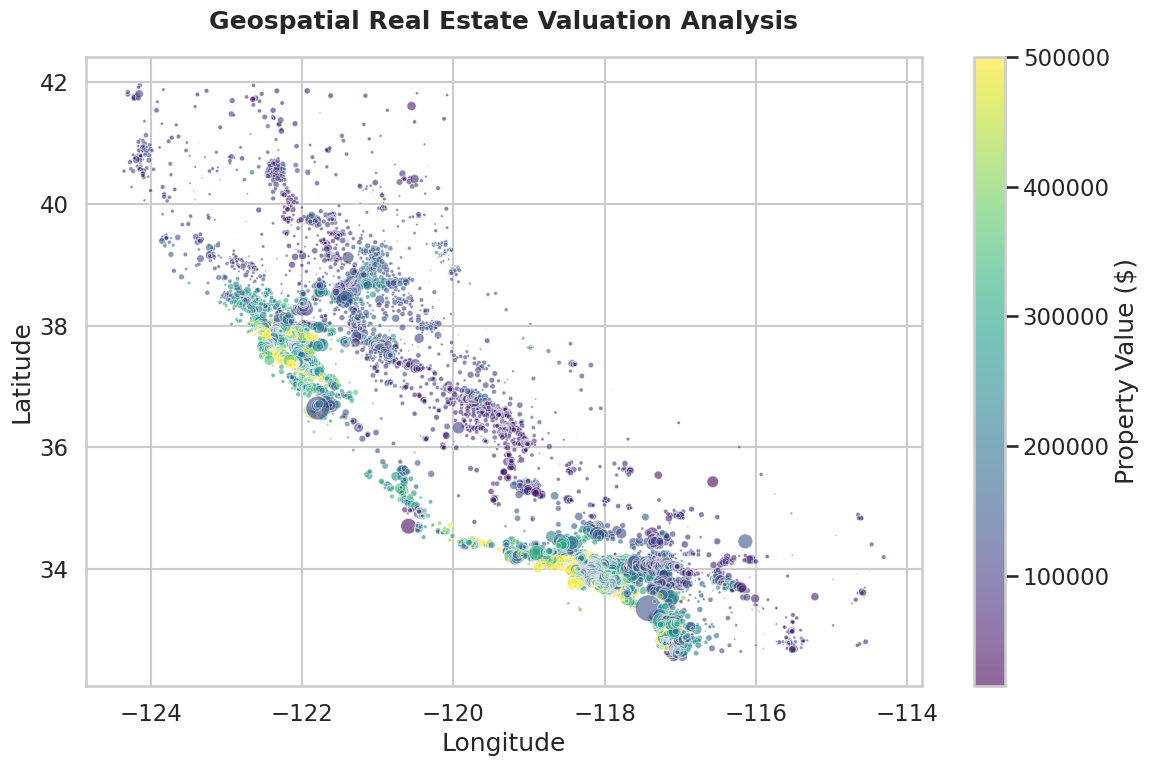

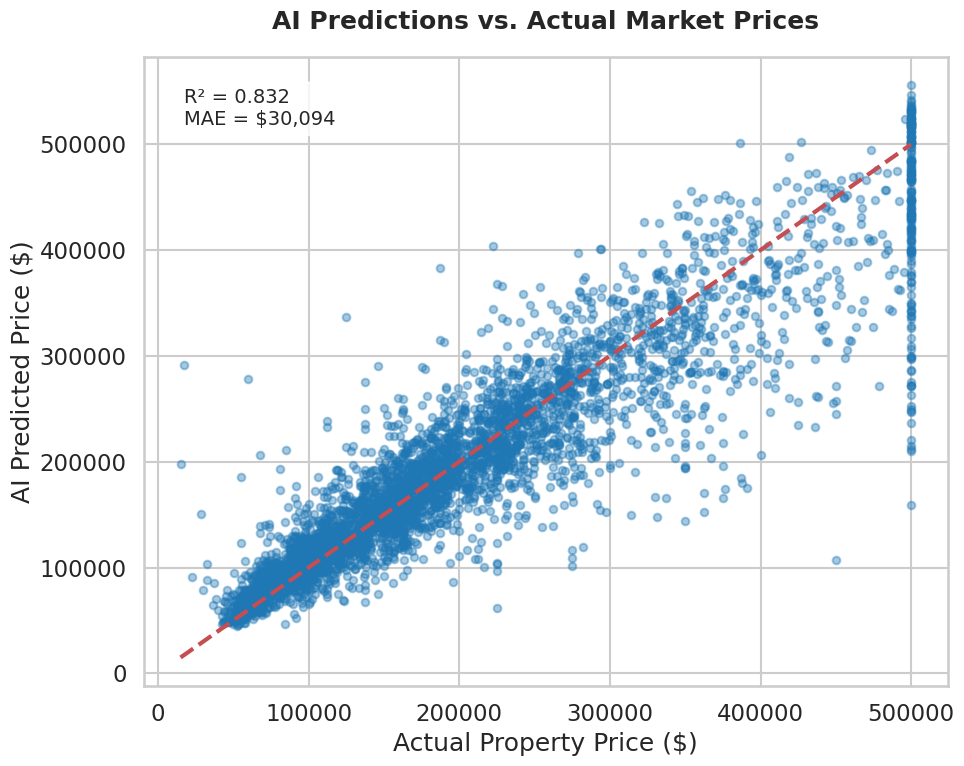

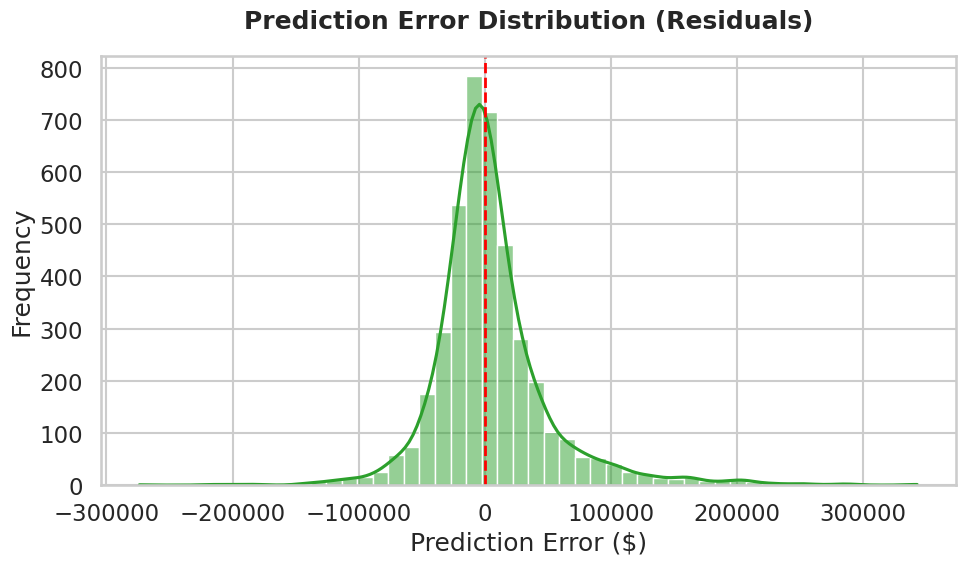

Calculating SHAP values for Explainable AI...


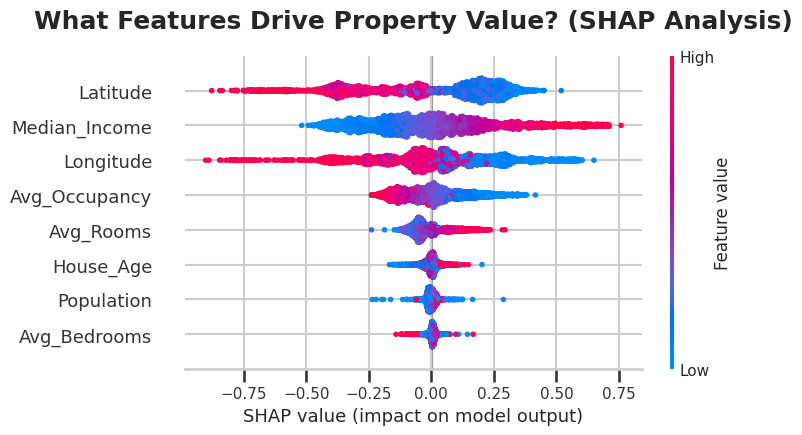


Code execution complete. Save these 4 images for your Khamsat Gig Gallery!


In [ ]:
# ==========================================
# 1. INSTALL AND IMPORT LIBRARIES
# ==========================================
!pip install -q xgboost shap scikit-learn matplotlib seaborn pandas numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Set professional plotting style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 8)

# ==========================================
# 2. LOAD & PREPARE BUSINESS DATA
# ==========================================
print("Loading Spatial Real Estate Dataset...")
data = fetch_california_housing(as_frame=True)
df = data.frame

# Scale the target to actual Dollars for realistic business presentation (original is in 100k)
df['Price'] = df['MedHouseVal'] * 100000
df.drop('MedHouseVal', axis=1, inplace=True)

# Rename columns for professional presentation
df.rename(columns={
    'MedInc': 'Median_Income',
    'HouseAge': 'House_Age',
    'AveRooms': 'Avg_Rooms',
    'AveBedrms': 'Avg_Bedrooms',
    'Population': 'Population',
    'AveOccup': 'Avg_Occupancy'
}, inplace=True)

X = df.drop('Price', axis=1)
y = df['Price']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 3. SENIOR ENGINEERING: LOG TRANSFORM & MODELING
# ==========================================
# Financial data is skewed. We log-transform the target for robust training.
y_train_log = np.log1p(y_train)

print("Training Advanced XGBoost Regressor...")
# Build a robust pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    ))
])

pipeline.fit(X_train, y_train_log)

# Predict and reverse the log transformation using expm1
y_pred_log = pipeline.predict(X_test)
y_pred = np.expm1(y_pred_log)

# ==========================================
# 4. BUSINESS METRICS EVALUATION
# ==========================================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- MODEL PERFORMANCE METRICS ---")
print(f"R² Score: {r2:.4f} (Explains {r2*100:.1f}% of price variance)")
print(f"Mean Absolute Error (MAE): ${mae:,.2f} per property")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}\n")

# ==========================================
# 5. GENERATE 4 PORTFOLIO-READY VISUALS
# ==========================================
print("Generating High-Quality Gallery Visuals...\n")

# Visual 1: Geospatial Pricing Heatmap (Business Intelligence)
plt.figure(figsize=(12, 8))
scatter = plt.scatter(x=df['Longitude'], y=df['Latitude'],
                      c=df['Price'], cmap='viridis',
                      s=df['Population']/100, alpha=0.6, edgecolors="w", linewidth=0.5)
plt.colorbar(scatter, label='Property Value ($)')
plt.title('Geospatial Real Estate Valuation Analysis', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

# Visual 2: Actual vs. Predicted Prices (Reliability Proof)
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.4, color='#1f77b4', s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3)
plt.title('AI Predictions vs. Actual Market Prices', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Actual Property Price ($)')
plt.ylabel('AI Predicted Price ($)')
plt.text(0.05, 0.95, f'R² = {r2:.3f}\nMAE = ${mae:,.0f}',
         transform=plt.gca().transAxes, fontsize=14,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()

# Visual 3: Residual Error Distribution (Statistical Rigor)
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='#2ca02c', bins=50)
plt.axvline(x=0, color='red', linestyle='--', lw=2)
plt.title('Prediction Error Distribution (Residuals)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Prediction Error ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Visual 4: SHAP Explainable AI (What drives the price?)
print("Calculating SHAP values for Explainable AI...")
# Extract scaler and model to feed SHAP correctly
scaler = pipeline.named_steps['scaler']
xgb_model = pipeline.named_steps['model']
X_test_scaled = scaler.transform(X_test)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

plt.figure(figsize=(12, 8))
plt.title("What Features Drive Property Value? (SHAP Analysis)", fontsize=18, fontweight='bold', pad=20)
shap.summary_plot(shap_values, X_test, feature_names=X.columns, show=False)
plt.tight_layout()
plt.show()

print("\nCode execution complete. Save these 4 images for your Khamsat Gig Gallery!")